In [3]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [4]:
from utils.loaders import load_sweep
from utils.styles import apply
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

apply(context="paper", col="single")

In [5]:
save_path = "/Users/niaggar/Results"
data = [
    ("0000_radius_0.02", r"R=20 $\mu$m"),
    ("0001_radius_0.04", r"R=44 $\mu$m"),
    ("0002_radius_0.06", r"R=60 $\mu$m"),
    ("0003_radius_0.07", r"R=70 $\mu$m"),
    ("0004_radius_0.17", r"R=175 $\mu$m")
]


In [6]:
WHICH = "coherent"    # "coherent" | "incoherent" | "enhancement"
CMAP  = "jet"
R_MAX_MRAD = None     # None = todo theta; o p.ej. 17.0 para recortar el borde

def polar_map(ax, prof, channel, which=WHICH, cmap=CMAP, robust=True):
    Z = prof.enhancement[channel]          # (n_theta, n_phi)
    theta = prof.theta * 1e3                     # mrad (radio)
    n_theta, n_phi = Z.shape

    # bordes de celda -> pcolormesh flat (X,Y una celda mas grande que Z)
    dth = np.diff(theta)
    th_edges = np.concatenate([[theta[0] - dth[0] / 2], theta[:-1] + dth / 2, [theta[-1] + dth[-1] / 2]])
    phi_edges = np.linspace(0.0, 2 * np.pi, n_phi + 1)   # borde izq. de cada bin

    PHI, TH = np.meshgrid(phi_edges, th_edges)

    if robust:
        vmin, vmax = np.percentile(Z, [2, 98])   # recorta colas de ruido
    else:
        vmin = vmax = None

    pc = ax.pcolormesh(PHI, TH, Z, cmap=cmap, shading="flat", vmin=vmin, vmax=vmax)

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    if R_MAX_MRAD is not None:
        ax.set_ylim(0, R_MAX_MRAD)
    ax.set_rlabel_position(135)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)
    return pc

# Linear Polarization study of RGD particles

In [7]:
folder = "study_rgd_particles__PLIN"
sweep_data = load_sweep(folder, base_path=Path(save_path))

data_keys = list(sweep_data.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


Loaded 5 datasets: ['0004_radius_0.17', '0003_radius_0.07', '0001_radius_0.04', '0002_radius_0.06', '0000_radius_0.02']


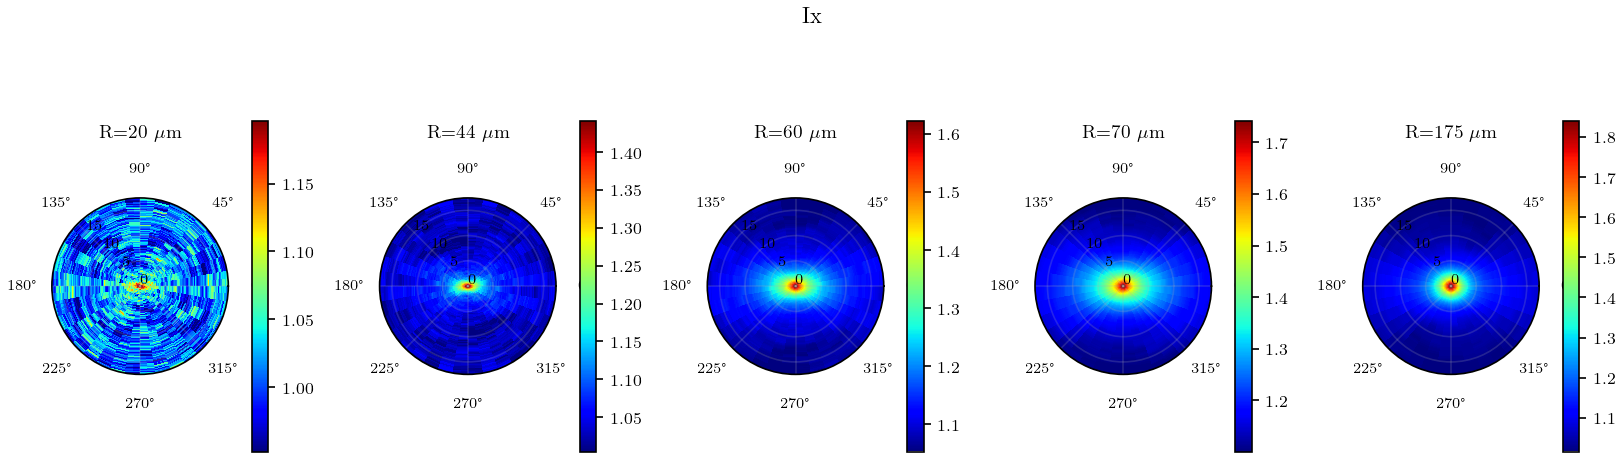

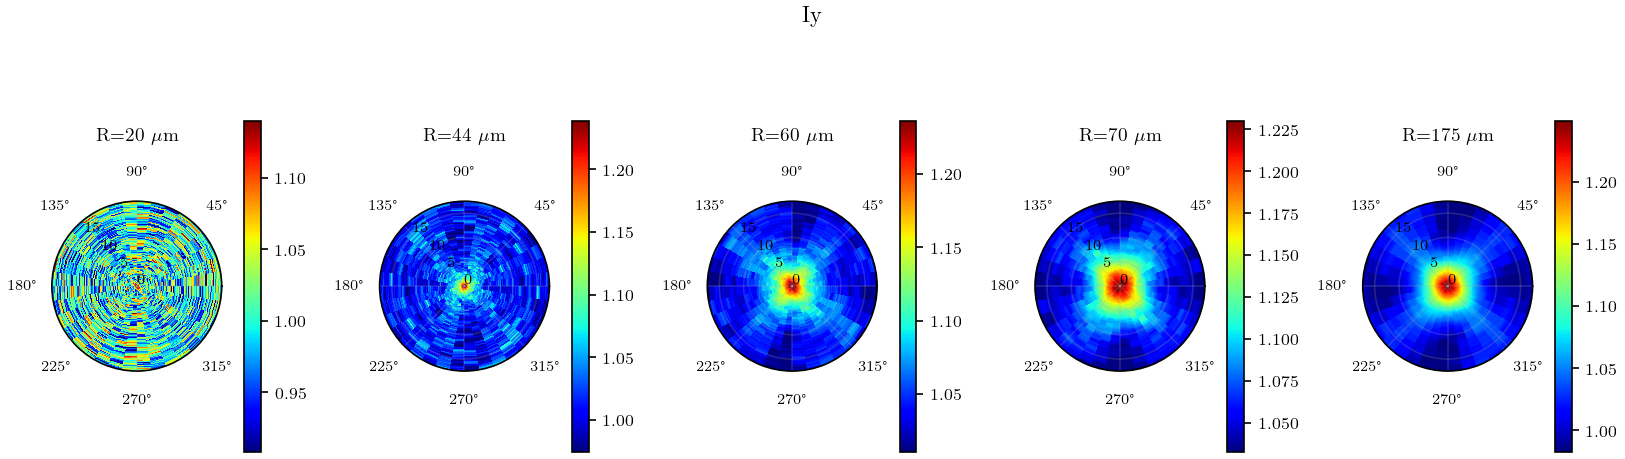

In [8]:
fig, axes = plt.subplots(
    1, 5, figsize=(11, 3.6),
    subplot_kw={"projection": "polar"},
)

fig.suptitle(r"Ix")


for ax, (ch, title) in zip(axes, data):
    prof = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=keep,
    )
    pc = polar_map(ax, prof, "co")
    ax.set_title(title, pad=12)
    fig.colorbar(pc, ax=ax, shrink=0.72, pad=0.10)

fig.tight_layout()
# fig.savefig(out, dpi=200)
plt.show()



fig, axes = plt.subplots(
    1, 5, figsize=(11, 3.6),
    subplot_kw={"projection": "polar"},
)

fig.suptitle(r"Iy")

for ax, (ch, title) in zip(axes, data):
    prof = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=keep,
    )
    pc = polar_map(ax, prof, "cross")
    ax.set_title(title, pad=12)
    fig.colorbar(pc, ax=ax, shrink=0.72, pad=0.10)

fig.tight_layout()

# fig.savefig(out, dpi=200)
plt.show()


## Linear Polarization ZOOM

In [9]:
folder = "study_rgd_particles_ZOOM__PLIN"
sweep_data = load_sweep(folder, base_path=Path(save_path))

data_keys = list(sweep_data.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


Loaded 5 datasets: ['0004_radius_0.17', '0003_radius_0.07', '0001_radius_0.04', '0002_radius_0.06', '0000_radius_0.02']


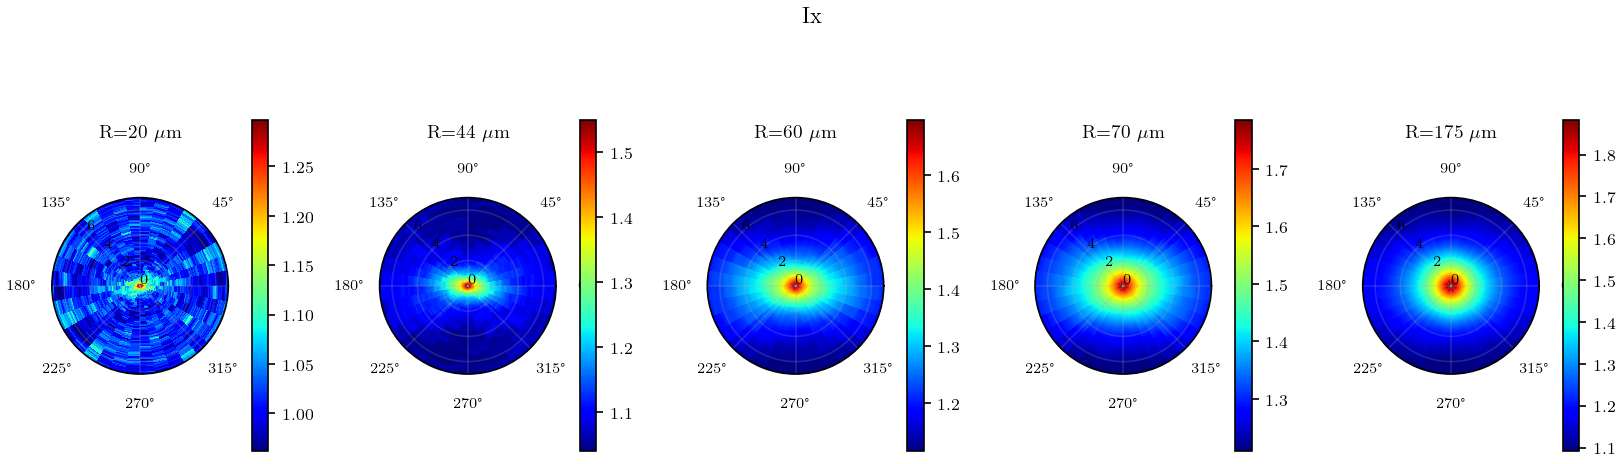

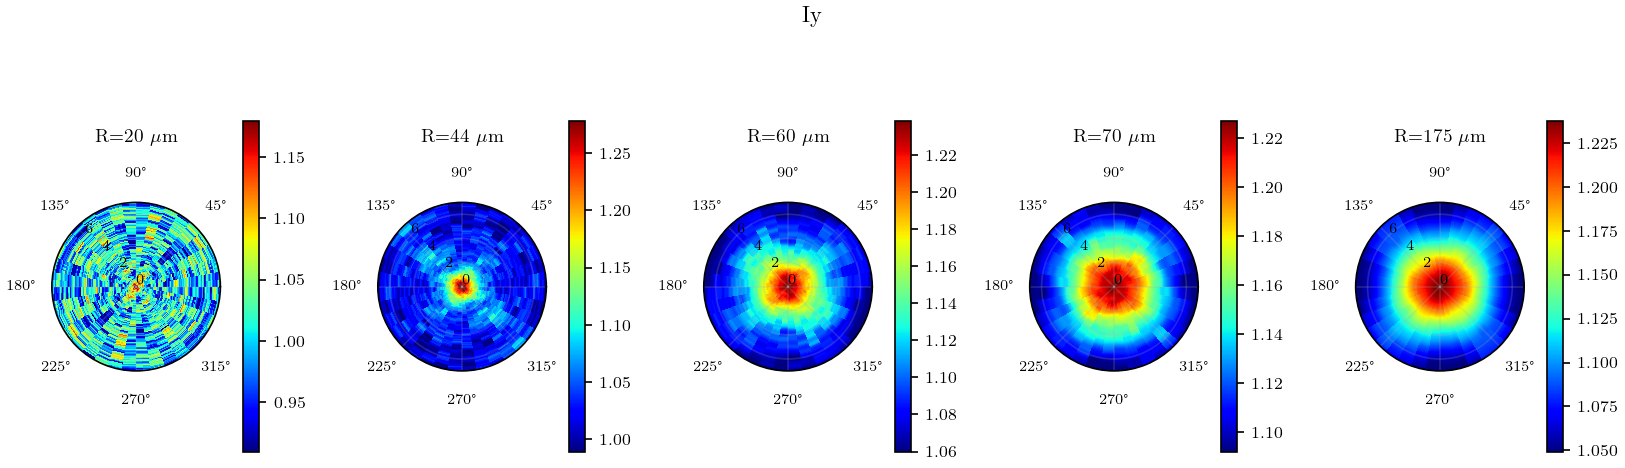

In [10]:
fig, axes = plt.subplots(
    1, 5, figsize=(11, 3.6),
    subplot_kw={"projection": "polar"},
)
fig.suptitle(r"Ix")
for ax, (ch, title) in zip(axes, data):
    prof = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=keep,
    )
    pc = polar_map(ax, prof, "co")
    ax.set_title(title, pad=12)
    fig.colorbar(pc, ax=ax, shrink=0.72, pad=0.10)

fig.tight_layout()
# fig.savefig(out, dpi=200)
plt.show()



fig, axes = plt.subplots(
    1, 5, figsize=(11, 3.6),
    subplot_kw={"projection": "polar"},
)
fig.suptitle(r"Iy")
for ax, (ch, title) in zip(axes, data):
    prof = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=keep,
    )
    pc = polar_map(ax, prof, "cross")
    ax.set_title(title, pad=12)
    fig.colorbar(pc, ax=ax, shrink=0.72, pad=0.10)

fig.tight_layout()
# fig.savefig(out, dpi=200)
plt.show()


# Circular Polarization study of RGD particles

In [11]:
folder = "study_rgd_particles__PCIR"
sweep_data = load_sweep(folder, base_path=Path(save_path))

data_keys = list(sweep_data.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")

Loaded 5 datasets: ['0004_radius_0.17', '0003_radius_0.07', '0001_radius_0.04', '0002_radius_0.06', '0000_radius_0.02']


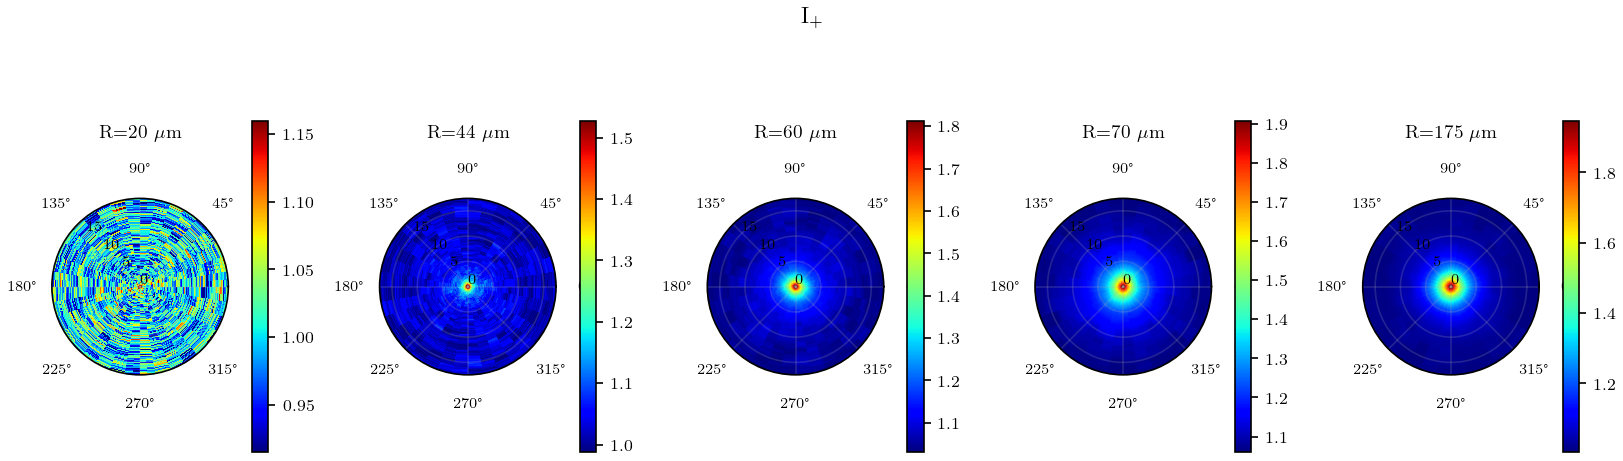

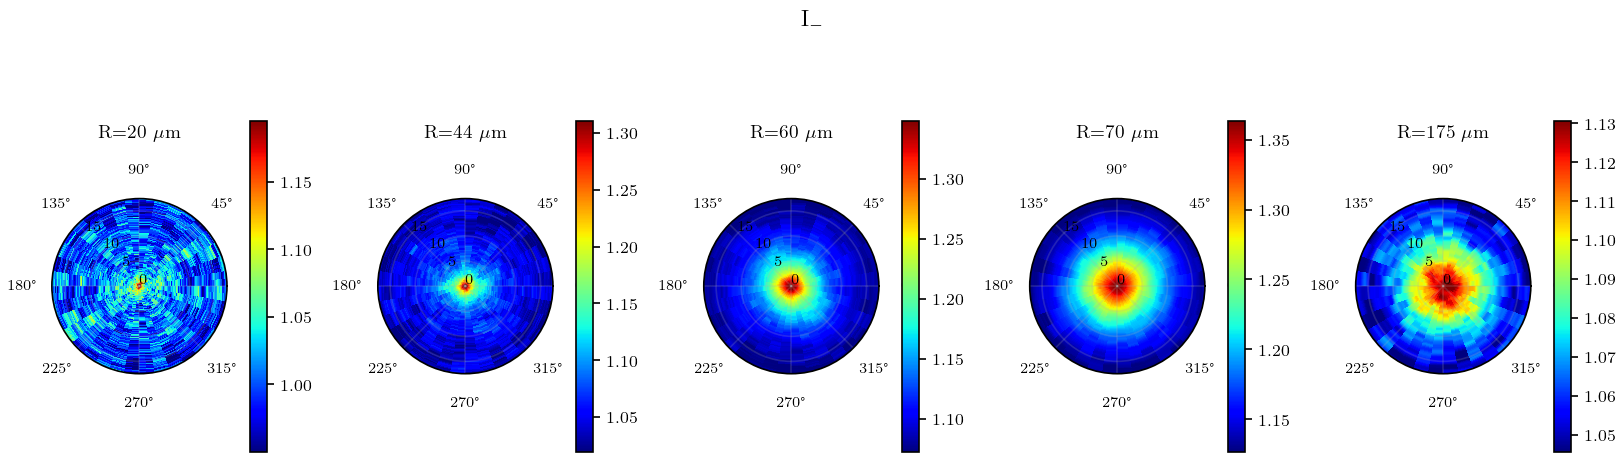

In [12]:
fig, axes = plt.subplots(
    1, 5, figsize=(11, 3.6),
    subplot_kw={"projection": "polar"},
)

fig.suptitle(r"I$_+$")
for ax, (ch, title) in zip(axes, data):
    prof = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=circular, time_index=0, reduce=keep,
    )
    pc = polar_map(ax, prof, "co")
    ax.set_title(title, pad=12)
    fig.colorbar(pc, ax=ax, shrink=0.72, pad=0.10)

fig.tight_layout()
# fig.savefig(out, dpi=200)
plt.show()



fig, axes = plt.subplots(
    1, 5, figsize=(11, 3.6),
    subplot_kw={"projection": "polar"},
)
fig.suptitle(r"I$_-$")
for ax, (ch, title) in zip(axes, data):
    prof = cbs_profiles(
        sweep_data[ch].processed_cbs("farfield_cbs"),
        basis=circular, time_index=0, reduce=keep,
    )
    pc = polar_map(ax, prof, "cross")
    ax.set_title(title, pad=12)
    fig.colorbar(pc, ax=ax, shrink=0.72, pad=0.10)

fig.tight_layout()
# fig.savefig(out, dpi=200)
plt.show()
